# **SMALL PROJECT: COVID19**
Sergi Marsol and Ariadna Mon \\
Modelling of Biomedical Systems \\
May 2023
## **DATA IMPORTING** 
The first step of our project is to import all the COVID19 data from the selected country. In our case, we will work with the data corresponding to Spain. The file obtained had data corresponding to confirmed cases, deaths, and recovered, all of these variables as a function of days. We both have saved the csv files gathering all the data in our Drive, to make it more practical to save the data into lists.   

In [1]:
# import data (Spain) and transform it to an array
import pandas as pd
import numpy as np

path='data/time_series_covid_19_confirmed.csv' #we determine the path from where to call the corresponding csv files with the data
confirmed = pd.read_csv(path, delimiter=",") #the delimiter of the csv files is a ',' so it is specified when reading the files
confirmed = confirmed.values.tolist() #we convert the string obtained from the read function to a list
confirmed1 = confirmed[235][4:] #the 235 row because it is the one corresponding to spain, and we start from the fourth column because it is when the data starts 
print(confirmed1)

path='data/time_series_covid_19_deaths.csv'
deaths = pd.read_csv(path, delimiter=",")
deaths = deaths.values.tolist()
deaths1 = deaths[235][4:]
print(deaths1)

path='data/time_series_covid_19_recovered.csv'
recovered = pd.read_csv(path, delimiter=",")
recovered = recovered.values.tolist()
recovered1 = recovered[235][4:]
print(recovered1)
print(len(recovered1)) #we want to confirm that the sizes of all the lists are the same
print(len(confirmed1))
print(len(deaths1))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 13, 15, 32, 45, 84, 120, 165, 222, 259, 400, 500, 673, 1073, 1695, 2277, 2277, 5232, 6391, 7798, 9942, 11748, 13910, 17963, 20410, 25374, 28768, 35136, 39885, 49515, 57786, 65719, 73235, 80110, 87956, 95923, 104118, 112065, 119199, 126168, 131646, 136675, 141942, 148220, 153222, 158273, 163027, 166831, 170099, 172541, 177644, 184948, 190839, 191726, 198674, 200210, 204178, 208389, 213024, 202990, 205905, 207634, 209465, 210773, 212917, 213435, 215216, 216582, 217466, 218011, 219329, 220325, 221447, 222857, 223578, 224350, 227436, 228030, 228691, 229540, 230183, 230698, 230698, 231606, 232037, 232555, 233037, 234824, 235290, 235772, 235400, 236259, 236259, 237906, 238564, 239228, 239479, 239638, 239932, 240326, 240660, 240978, 241310, 241550, 241717, 241966, 242280, 242707, 243209, 243605, 243928, 244109, 244328, 244683, 245268, 245575, 245938, 246272, 246504, 246752, 247086, 247486

## **SIR MODEL**
### **1. THEORETICAL BACKGROUND**
The SIR model is a commonly known mathematical model of epidemics, that is, the population can be divided into different several compartments, which are defined regarding the disease status. In this specific case, these are: susceptible (S; amount of population that risks being infected), infected (I; amount of population that is infected by the disease), and removed (R; individuals that are either dead or immune for life). 

The SIR model is defined with ordinary differential equations (ODEs), therefore being a deterministic model with continuous time, and according to the following parameters:


*   $r$, the infecivity of the disease
*   $a$, the constant per capita recovery rate

Consequently, the set of differential equations that drive the model are:

$\frac{dS}{dt}=-rSI$ \\
$\frac{dI}{dt}=rSI - aI$ \\
$\frac{dR}{dt}=aI$ 


In the following code block, the plot of the SIR model is displayed. 

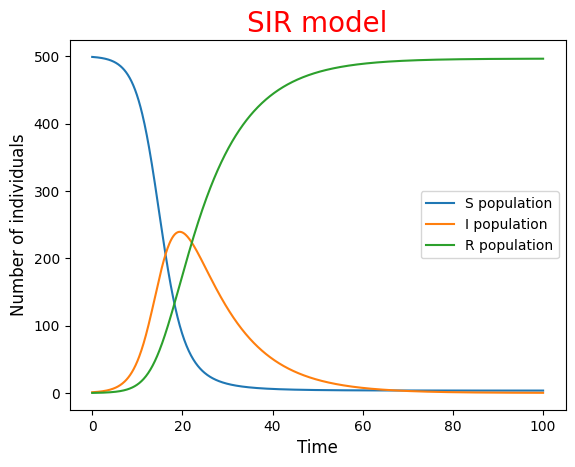

In [2]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import math

r_theory=1e-3
a_theory=1e-1
S0_theory=499
I0_theory=1
R0_theory=0
SIR0=[S0_theory,I0_theory,R0_theory]
t_theory=np.linspace(0,100,1000)
params=(r_theory,a_theory)

def SIR(ys_at_t, t, *parameters): 
    r = parameters[0]
    a = parameters[1]
    S,I,R = ys_at_t
    dSdt = -r*S*I
    dIdt = r*S*I - a*I
    dRdt = a*I
    return dSdt, dIdt, dRdt

SIR_theory = odeint(SIR, SIR0 , t_theory, args=params)
S_theory = SIR_theory[:,0]; I_theory = SIR_theory[:,1] ; R_theory = SIR_theory[:,2]

plt.figure()
plt.plot(t_theory, S_theory)
plt.plot(t_theory, I_theory)
plt.plot(t_theory, R_theory)
plt.xlabel("Time", fontsize = 12)
plt.ylabel("Number of individuals", fontsize = 12)
plt.title("SIR model", fontsize = 20, color="red")
plt.legend(labels=["S population", "I population", "R population"],loc='best')
plt.show()

### **2. DEFINITION OF VARIABLES**
Now we encounter ourselves with three lists that have the same size, 494 elements each, and what we want is to define the variables according to the SIR model as previously defined. In first place, the infected population will be defined with all the confirmed cases (in the confirmed list). However, the confirmed cases are cummulative, and if we plot it over time, the graph would be always increasing regardless of the rate of infection. Therefore, we will remove all the people who have died, as well as all the people who have recovered from the disease.

It is important to remark that in this case, the "recovered" compartment that we have just seen in the SIR model will be slightly modified, mainly due to the fact that whereas the model assumes that everyone ends in recovery, in reality there are also people who die, so both the dead and recovered people will account for the third compartment, which will be called Removed.

Another important consideration to make is that we will define the variables `time` and `start`; `time` corresponds to the time interval where we will study the COVID19 and fit it to the specific model, which in this case, will be the first wave of the epidemic, and `start` corresponds to the amount of days that will be removed from the data obtained from the COVID19 datasets used in order for the model and the real data to more or less start at the same time. Added to this, the variable `time` will be modified along the study depending on the fitting done at each time.

Finally, susceptible people will not be plotted yet because S0 is to be fitted, which is one of the many aims to do in this project. Therefore, both Removed and Infected will be plotted over time. As it can be shown, the amount of infected individuals has a peak at its maximum, and later on it decreases, whereas the removed people only increase over time.

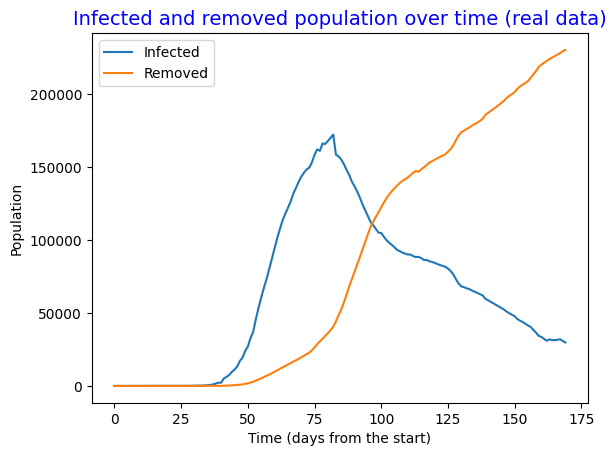

In [3]:
#we separate the values in variables
infected = [] #we define the variables as lists
removed = []
time=180 #we determine the time interval to later do the fitting with our model
start=10 #we start with some delay in order for the signals to fit better

for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i]) #we substract from the confirmed cases all the deaths and the recovered individuals
  removed.append(deaths1[i]+recovered1[i]) #we add both the dead and the recovered people to the remove compartment

#susceptible = s0 - confirmed
dt=np.linspace(0,time-1-start,time-start) #we define the time variable according to the start and the end 


#we plot the data to see the behavior
plt.figure()
plt.plot(dt,infected) 
plt.plot(dt,removed)
plt.xlabel("Time (days from the start)")
plt.ylabel("Population")
plt.title("Infected and removed population over time (real data)", color='blue',fontsize=14)
labels=['Infected','Removed']
plt.legend(labels)
plt.show()

### **3. FITTING OF $r$ AND $S_{0}$**
The main aim of this project is to fit, as better as possible, the models to the data. In order to adapt the SIR model to the real COVID19 data that we have selected, we have to personalize the model by tuning some parameters. The two parameters that we will be now fitting are $r$ (infectivity) and $S_{0}$, which determines the initial amount of susceptible people among the population. On the other hand, the other parameter (recovery) already has a given value, $a=1/2.3$ $days^{-1}$. 

To accomplish our objectives, we will re-declare the variables of the data, as done in the previous step, but with a delay of 15 days since the 10 days-delay has been done to take a better look at the plot that we have just seen. 

The fitting will be done in the following way: only the increasing wave will be fitted, theoretically, and as a result, a set of values will be fixed for parameters $r$ and $S_{0}$, which will be the ones that give the less amount of error when the modelled data is compared to the real one. Nonetheless, we will take a little section of the decreasing wave as well to do the fitting because our data presents a lot of asymmetry. 

Before carrying the final tuning of the parameters, an initial rougher tuning of the parameters has been carried out in order to determine a specific interval of values for both of them. The initial range of values taken for $r$ was $[10^{-9},10^{-1}]$, whereas the initial range of values for $S_{0}$ was $[10^{5},10^{8}]$. Since then, we have been reducing this range to obtain the parameters that give the most optimal output. 

The code below is the final finer tuning of the parameters, where the intervals for each one of them are: $[10^{-7},2·10^{-7}]$ for $r$ and $[4·10^{6},5·10^{6}]$ for $S_{0}$. It may appear as a shock that the maximum value for $S_{0}$ is $5·10^{6}$ giving that the actual population of Spain is 47 million people, approximately. The fitting works better with lower values due to the fact that having an initial population of 47 million people would result in the assumption that the infectious people are in contact with the whole population, and that is not quite the case. This is the reason why the fitting of $S_{0}$ is relevant in this project, in order to fit our model as similar as possible to the real data. 

The next step is to run the model to find the best combination of the two parameters, and to come to a conclusion, the root mean squared error will be calculated between the resulting modelled signal and the real one, until an optimal resulting combination of values is met. In addition, a relative error will also be calculated for us to know how the model works. This calculation will be done by predicting (both with the real and modelled data) the time required for the pandemics to be reduced to a 30%, and we will compare the values obtained. This will be done, however, in the evaluation of the model later on.


The minimum RMSE is: 26335.09 with r: 1.45e-07 and S0: 4241379.31


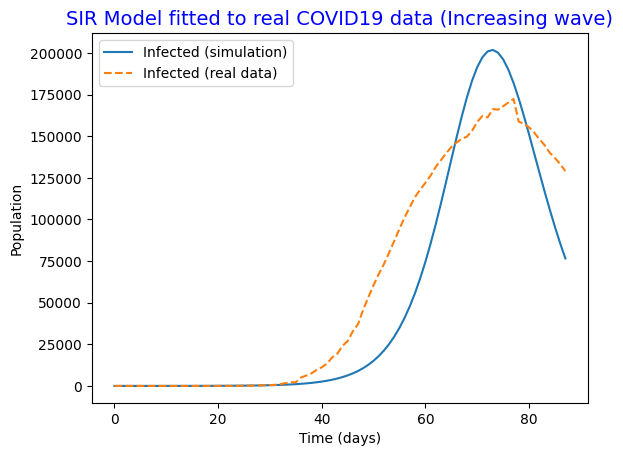

In [4]:
#SIR MODEL, FITTING OF r AND s0 ON THE "INCREASING" WAVE 

#Definition of variables (real data)
infected = []
removed = []
time=180
start=15 #we redefine the delay as 15

for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i]) #the infected data is re-defined substracting again the dead and recovered from the new start
  removed.append(deaths1[i]+recovered1[i])

#susceptible = s0 - confirmed1

index_max=infected.index(max(infected)) #since we only fit the increasing wave, we must find the peak of I 
increasing_wave=87 #the maximum is 77 (peak location), but we will delay the fitting to 87 days instead because of the asymmetry if the data

infected1=infected[0:increasing_wave+1] #we only take the infected data up to the peak previously found
n=increasing_wave+1 #this variable will define the length of the arrays of I, R and S
dt=np.linspace(0,increasing_wave,increasing_wave+1) #this is the time variable of the differential equations

#The SIR model function is defined
 #the outputs are the corresponding differential equations

#Initialization of parameters
rates = np.linspace(1e-7,2e-7,num=30) #we define the different r values with the logspace function
S0 = np.linspace(4e6,5e6,30) #we define the different s0 values with the linspace function
a =1/2.3 #a corresponds to the recovery rate, which is determined by the days of recovery (2.3 days)
I0=2 #we take 2 as initial infected people because it is the value which we start with in the real data
R0=0 #at first, no one is recovered yet

#Fitting of r and s0
rmserrors=np.zeros((len(rates),len(S0))) #we define a 2D array that corresponds to the rms errors with each combination of r and s0

#we define each variable as a 3D array, containing a whole data series for each combination of parameters 
S=np.zeros((n,len(rates),len(S0)))
I=np.zeros((n,len(rates),len(S0)))
R=np.zeros((n,len(rates),len(S0)))

#we go through all the combinations, calculating the error in every case
for i in range(len(rates)):
  params = (rates[i],a)
  for j in range(len(S0)):
    y0 = (S0[j],I0,R0)
    Y = odeint(SIR, y0, dt, args=params, hmax = 1.0) #the odeint function solves the differential equation and results in population data
    S[:,i,j] = Y[:,0]; I[:,i,j] = Y[:,1]; R[:,i,j] = Y[:,2];
    mse = np.square(np.subtract(infected1, I[:,i,j])).mean() 
    rmse = math.sqrt(mse)
    rmserrors[i,j]=rmse

#we find the minimum error and its index
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)
opt_r=rates[index[0]] #we index the optimal r
opt_s0=S0[index[1]] #we index the optimal s0

#We print our results of the fitting (the optimal value for the parameteres)
print ('The minimum RMSE is: ' + str(round(min_error,2)) + ' with r: ' + str(round(opt_r[0],9)) + " and S0: " + str(round(opt_s0[0],2)))

#We plot the real data over the model and compare it.
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, I[:,index[0],index[1]], label="Infected (simulation)")
plt.plot(dt, infected1, '--', label='Infected (real data)')
plt.title("SIR Model fitted to real COVID19 data (Increasing wave)", color='blue', fontsize=14)
plt.legend()
plt.show()

### **4. EVALUATION OF THE MODEL ON THE DECREASING WAVE**

At this point, the model has already been tuned with the parameters that result in the best outcome. However, we have only fitted the increasing wave, and we will now proceed to compare the model done on the data that corresponds to the decreasing wave (remember we have taken also a little section of the decreasing wave to do the fitting, so the evaluation will be done on the section left of the decreasing wave). 

In addition, we will use this model to predict approximately when the epidemics will end. This will be done by considering the end to be when the infected population reaches a 10% of its maximum. However, in this case the 10% of the maximum infected population will not be considered as the threshold to assume the epidemic has ended, and this is mainly because the real data does not reach this value on the decreasing wave (at least not on the first wave). That is the reason why we have used the 30% of the peak instead.


The root mean squared error is: 64766.26


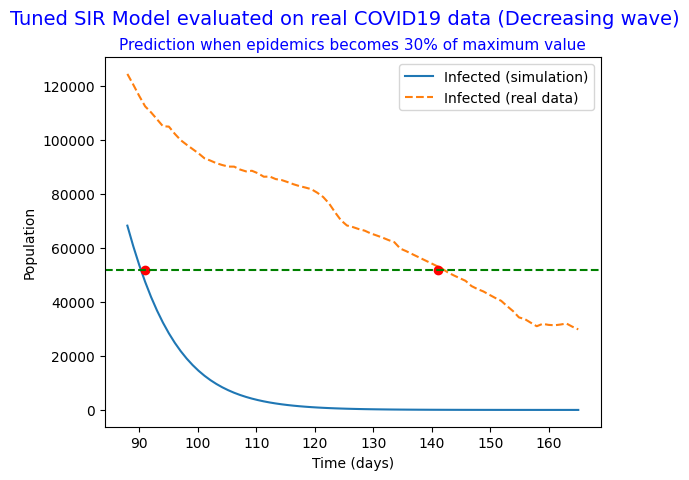

Pandemic is at its 30% after 91 days, so the 6th of May, 2020 (according to simulation).
Pandemic is at its 30% after 141 days, so the 26th of July, 2020 (according to real data).
Error of prediction between model and real data: 50 days.


In [5]:
#MODEL SIR, EVALUATION OF MODEL ON THE "DECREASING" WAVE 

#we re-define the variables to now take only the values corresponding to the decreasing wave 
infected = []
removed = []
time=180
start=15

for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i])
  removed.append(deaths1[i]+recovered1[i])

#susceptible = s0 - confirmed1

index_max=infected.index(max(infected)) 
infected1=infected[increasing_wave+1:] #now we take only the real data that goes from the peak (and a little more) to the end of the time interval

dt=np.linspace(0,time-1-start,time-start) #this is the time variable in general
dt1=np.linspace(increasing_wave+1,time-start,time-increasing_wave-start-1) #this is the time variable of the differential equations in this specific case 

#The parameters are initialized as in the previous code
a =1/2.3 #in days
I0=2
R0=0
params = (opt_r,a)
y0 = (opt_s0,I0,R0)

#we solve the differential equations
Y = odeint(SIR, y0, dt, args=params, hmax = 1.0)
S = Y[:,0]; I = Y[:,1]; R = Y[:,2];

#in this case, only one error will be computed, which will determine the performance of the previously tuned model
mse = np.square(np.subtract(infected1, I[increasing_wave+1:])).mean() 
rmse = math.sqrt(mse)
print('The root mean squared error is: ' + str(round(rmse,2)))

#Last, we obtain the time at which the epidemics is supposed to end for real and modelled data
val=max(infected)*0.3 #as we have explained, we will take the 30% of the maximum infected population

#we find it for the modelled infected
trobat=False
i=increasing_wave
idx1=0
while i<(len(I)) and not trobat:
  if I[i]<val:
    trobat=True
    idx1=i
  i+=1

#we also find it for the real infected
i=0
idx2=0
trobat=False
while i<len(infected1) and not trobat:
  if infected1[i]<val:
    trobat=True
    idx2=i+increasing_wave
  i+=1

#we plot the results again
plt.figure(3)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, I[increasing_wave+1:], label="Infected (simulation)")
plt.plot(dt1, infected1,  '--', label='Infected (real data)')
plt.plot(idx1,val,'ro')
plt.plot(idx2,val,'ro')
plt.axhline(y=val, color='g', linestyle='--' )
plt.suptitle("Tuned SIR Model evaluated on real COVID19 data (Decreasing wave)", color='blue', fontsize=14)
plt.title('Prediction when epidemics becomes 30% of maximum value', fontsize=11, color='blue')
plt.legend()
plt.show()

print("Pandemic is at its 30% after " + str(idx1) + " days, so the 6th of May, 2020 (according to simulation).")
print("Pandemic is at its 30% after " + str(idx2) + " days, so the 26th of July, 2020 (according to real data).")
print("Error of prediction between model and real data: " + str(idx2-idx1) + " days.")

### **5. ANALYSIS OF BASIC REPRODUCTIVE RATIO AND EPIDEMICS**

A very relevant parameter in epidemics is the basic reproductive ratio $R_{0}$, which is defined as the average number of secondary cases transmitted by a single infected individual that is placed into a fully susceptible population, so it basically tells us about the initial spread of the disease. If $R_{0}>1$ there will be an epidemic, and if $R_{0}<1$ the new infected will either recover or die without being replaced by other infections.

The final step of this section consists in taking into consideration the parameter $R_{0}$ to predict when the epidemic will start decreasing (when it reaches its peak). We will also compute when the derivative of the infected signal stops being positive. To do it, the whole wave will be studied instead of only either the decreasing or increasing part.

where R0 < 1: 73 days, so 19th April, 2020.
where dI/dt < 0: 73 days, so 19th April, 2020.


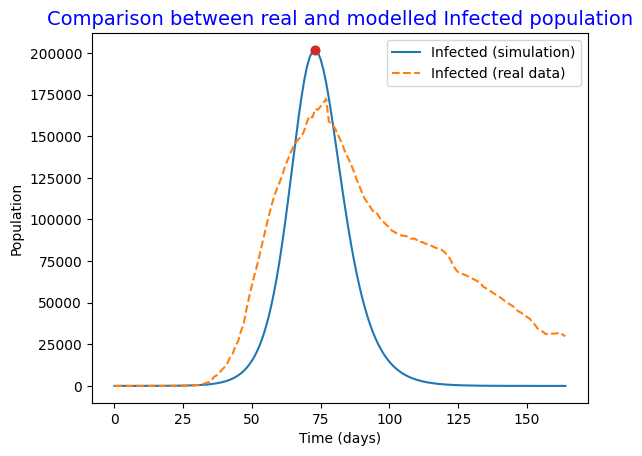

In [6]:
#We also start initializing the variables
r = opt_r
S0 = opt_s0
a =1/2.3 #in days
I0=2
R0=0
params=(r,a)
y0 = (S0,I0,R0)

#we solve the differential equations
Y = odeint(SIR, y0, dt, args=params, hmax = 1.0)
S = Y[:,0]; I= Y[:,1]; R = Y[:,2];

#we define the corresponding parameters for this part
r0=r*S/a #definition of R0
Imax=max(I) #at this point, the derivative of I will be 0
idx1=np.where(I==Imax) #we look for the index where the peak is located
idx2=np.where(r0<1) #and we also look for the index where R0 starts being smaller than 1
idx2=idx2[0][0]
idx1=idx1[0][0] #we add one unit to the index where dI/dt equals 0 because we have found where the peak is and not where it starts being negative
print("where R0 < 1: " + str(idx2) + " days, so 19th April, 2020.")
print("where dI/dt < 0: " + str(idx1) + " days, so 19th April, 2020.")

#we plot the overall results
plt.figure(4)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, I, label="Infected (simulation)")
plt.plot(dt, infected, '--', label='Infected (real data)')
plt.plot(idx2,I[idx2],'o') #we mark the first point where R0 < 1
plt.plot(idx1,I[idx1],'o') #and dI/dt <0 (it's the same value)
plt.title("Comparison between real and modelled Infected population", fontsize=14, color='blue')
plt.legend()
plt.show()

### **6. CONCLUSIONS ON SIR MODEL**

Now that we have fitted and tested the model on all the infected data for the first wave of the COVID19 pandemics, we can conclude on several aspects. In the first place, while the fitting of the increasing wave shows more accurate results, it is evident that the tuned model does not fit well with the decreasing wave. This is mostly due to the fact that whereas our model is symmetrical, the real data we are working with is not, resulting in a big difference in the modelled and real decreasing waves. The root mean squared error (RMSE) of the fitting is 26335.09 people, while the RMSE between the tuned model and the real data is 64766.26 people, higher than with the fitting, as it is expected. In addition, as we have previously seen in the code, we have also calculated the prediction error between the model and the real data on the 30% of the maximum infected population, which is of 50 days. Consequently, it can be concluded that the SIR model is not quite accurate, because 50 days represent nearly 2 months, which is a large period of time to predict wrongly in actual epidemiology studies, therefore the model cannot be trusted.

Also, while the asymmetry in the data is one of the reasons why our model does not work well, there are many other factors:


*   The SIR model assumes the population to be a closed system, so migrations are in fact neglected. Added to this, although deaths are considered in the Removed compartment of the model, births are not. 
*   The disease presents a level of complexity that is not contemplated on the model: there are different levels of severity, and the duration of recovery or infection varies significantly depending on the individual. The model, however, assumes an homogeneous population. 
*   Another evident drawback is the lack of more compartments in the model: there are only three considered and this is not enough to depict the different phases of the disease.
*   This factor has already been mentioned before; the SIR model assumes a well-mixed population, when in reality not all population is in contact with each other. This has been taken into account by fitting $S_{0}$, but still, the correct considerations are still not made: the initial susceptible population has been lowered to obtain better results, but in real life the susceptibility to become infected also depends gender, age, correct accomplishment of health guidelines, etc. 

Finally, another very relevant aspect to justify the output of the model is the lack of consideration of lockdown (or quarantine). However, the effects of this intervention measured will be overcome on the following section of the project. 









## **SIR MODEL: QUARANTINE**

For this section, quarantine will be taken into account to carry out a better model tuning. We will first proceed to fit the model to the data during the days where quarantine was not implemented, with the main aim to obtain the parameters $r$ and $S_{0}$. 

### **1. FITTING OF $r$ AND $S_{0}$**

It is important to remark that when looking at the real data, the days that had passed from the start to where the lockdown started were 52 days. However, this number of days did not result a good fitting and the quarantine factor obtained was approximately zero, so we have assumed the quarantine to start after 72 days (the graph does not reach 72 days, but remember this is because the 72 days are counted from the actual start of the real data, and  we have taken out some delay in the firsts steps of the project). It actually makes sense that more days are needed for the SIR model to equalize the real data due to the fact that the model does not take into account the incubation period of the disease; there may be people that, despite being in lockdown, are able to develop the disease because of previous infection. Consequently, there may be some time needed to stabilize the population so that no new COVID19 cases appear. 

As well as in the previous case, the code below represents a finer tunning where the interval values taken for each parameter are: $[10^{-7}, 3·10^{-7}]$ for $r$ and $[4·10^{6},6·10^{6}]$ for $S_{0}$. 

The minimum RMSE is: 6716.508049580354 with r: 1.1e-07 and S0: 5586206.9


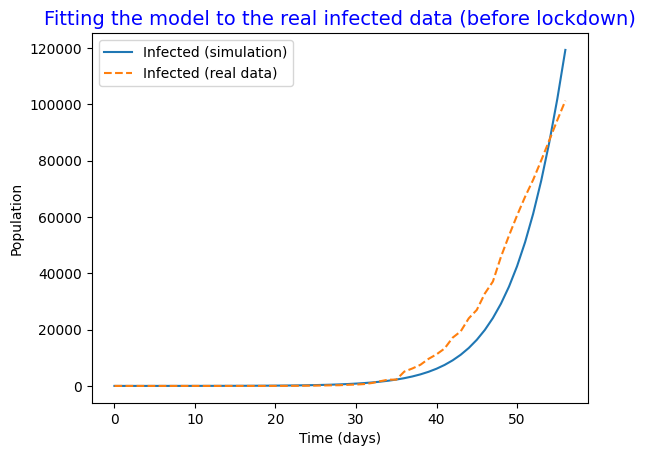

In [7]:
#QUARANTINE
#Model SIR, fitting of r and s0
from scipy.integrate import odeint
import math

#we define the variables again
infected = []
removed = []
time=180
start=15

for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i])
  removed.append(deaths1[i]+recovered1[i])

#susceptible = s0 - confirmed1
time=72 #we define the time to be 72 days, which is when the quarantine is assumed to start

infected1=infected[0:time-start]
n=time-start
dt=np.linspace(0,time-start-1,time-start)

#we define a series of values for r and s0, and we initialize the parameters
rates = np.linspace(1e-7,3e-7,num=30) 
S0 = np.linspace(4e6,6e6,30)
a =1/2.3 #in days
I0=2
R0=0

#we create the arrays that will collect the modelled data
rmserrors=np.zeros((len(rates),len(S0)))
S=np.zeros((n,len(rates),len(S0)))
I=np.zeros((n,len(rates),len(S0)))
R=np.zeros((n,len(rates),len(S0)))

#we run a loop where we will calculate the rms errors comparing the real and modelled data
for i in range(len(rates)):
  params = (rates[i],a)
  for j in range(len(S0)):
    y0 = (S0[j],I0,R0)
    Y = odeint(SIR, y0, dt, args=params, hmax = 1.0)
    S[:,i,j] = Y[:,0]; I[:,i,j] = Y[:,1]; R[:,i,j] = Y[:,2];
    mse = np.square(np.subtract(infected1, I[:,i,j])).mean() 
    rmse = math.sqrt(mse)
    rmserrors[i,j]=rmse

#we obtain the minimum error
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)

#we obtain the optimal combination of r and s0 parameters
opt_r=rates[index[0]]
opt_s0=S0[index[1]]
print ('The minimum RMSE is: ' + str(min_error) + ' with r: ' + str(round(opt_r[0],8)) + " and S0: " + str(round(opt_s0[0],2)))

#we plot the results
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, I[:,index[0],index[1]], label="Infected (simulation)")
plt.plot(dt, infected1, '--', label='Infected (real data)')
plt.title("Fitting the model to the real infected data (before lockdown)", color='blue', fontsize=14)
plt.legend()
plt.show()

#we take the last conditions of all three variables so that we know the initials conditions for the next step
I1 = I[-1,index[0],index[1]][0]
S1 = S[-1,index[0],index[1]][0]
R1 = R[-1,index[0],index[1]][0]

As it can be seen, the model is more or less well fitted to this initial section of the wave. And the RMSE is of 6716.51 people.

### **2. FITTING OF THE QUARANTINE FACTOR $q$**

The quarantine factor $q$ will be fitted in this case, which corresponds to the amount of infected population that is isolated and therefore can not infected anyone else. We will use the optimal $r$ and $S_{0}$ that have been already fitted and we will fix them in this case. Added to this, we will fit the section of increasing wave left as well as a section of the decreasing wave, in order for the fitting to work better. A rougher tunning has been done first to see the ranges of values where $q$ lays, and the code below shows the final finer tunning carried out, where the interval set is $[10^{-2},10^{-1}]$. 

The minimum RMSE is: 79982.2 with q: 0.01


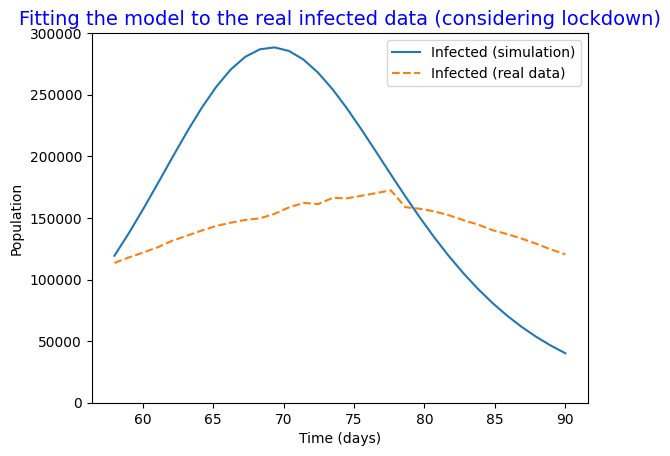

In [8]:
timef = 90 #we take until half of the decreasing wave to do the fitting

#we redefine the time interval and the infected real data in this time range
dt1=np.linspace(time-start+1,timef,timef-time+start-1)
infected1=infected[time-start+1:timef]
n = timef+start-time-1

#we define a new function that takes into account the quarantine factor q 
def qSIR(ys_at_t, t, *parameters):
    r = parameters[0]
    a = parameters[1]
    q = parameters[2]
    S,I,R = ys_at_t
    dSdt = -r*S*I
    dIdt = r*S*I - a*I - q*I
    dRdt = a*I + q*I
    return dSdt, dIdt, dRdt

#we initialize the factor q with a series of values (finer tuning)
qs = np.linspace(1e-2,3e-3,30)

#the variables that we already know are initialized
a =1/2.3 #in days
rmserrors=np.zeros((len(qs),1))
S=np.zeros((n,len(qs)))
I=np.zeros((n,len(qs)))
R=np.zeros((n,len(qs)))

#we take the final conditions of the last step as initial conditions
y0 = (S1,I1,R1)

#we run a loop for all the q values to obtain the best output
for i in range(len(qs)):
  params = (opt_r,a, qs[i])
  Y = odeint(qSIR, y0, dt1, args=params, hmax = 1.0)
  S[:,i] = Y[:,0]; I[:,i] = Y[:,1]; R[:,i] = Y[:,2];
  mse = np.square(np.subtract(infected1, I[:,i])).mean() 
  rmse = math.sqrt(mse)
  rmserrors[i]=rmse

#we obtain the minimum error and determine the optimal q
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)[0][0]
opt_q=qs[index]
print ('The minimum RMSE is: ' + str(round(min_error,2)) + ' with q: ' + str(round(opt_q,3)))

#we plot the results
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, I[:,index], label="Infected (simulation)")
plt.plot(dt1, infected1, '--', label='Infected (real data)')
plt.ylim(0,300000)
plt.title("Fitting the model to the real infected data (considering lockdown)", color='blue', fontsize=14)
plt.legend()
plt.show()

#we define the last conditions of the variables as the initial conditions for the next step
I2 = I[-1,index]
S2 = S[-1,index]
R2 = R[-1,index]

It will be later discussed, but as the graph shows, the quarantine in the SIR model does not seem to work very well, and the RMSE obtained is 79982.2. people.

### **3. EVALUATION OF THE MODEL ON THE DECREASING WAVE**

For this last step of the SIR Model analysis, this case considering lockdown as well, the evaluation of the tuned model on the decreasing wave is done. Therefore, now we will take the optimal results of the parameters $r$, $S_{0}$ and $q$. The same that was done for the evaluation of the SIR model on the decreasing wave without quarantine will be done in this case to calculate the prediction error. However, since the fitting is done by segments a 20% of the maximum infected population will be taken instead for this case.

The root mean squared error is: 66383.87


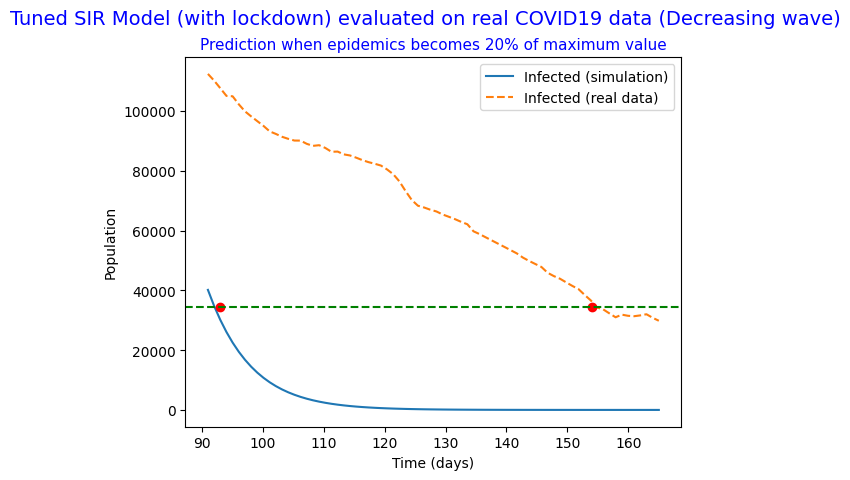

Pandemic is at its 30% after 93 days, so May 9th 2020 (according to simulation).
Pandemic is at its after 154 days, so September 9th, 2020. (according to real data).
Error of prediction between model and real data: 61 days.


In [9]:
#Finally, we will test the model to the data
end = 180 #we take the end of the data 

#we define again the time ranges and the real data according to it
dt1=np.linspace(timef+1,end-start,end-start-timef-1)
infected1=infected[timef+1:]
n = end-start-timef-1

#we initialize the variables with the correct values
a =1/2.3 #in days
y0 = (S2,I2,R2)
params = (opt_r, a, opt_q)
Y = odeint(qSIR, y0, dt1, args=params, hmax = 1.0)
S = Y[:,0]; I = Y[:,1]; R = Y[:,2];

#and we find the rmse obtained
mse = np.square(np.subtract(infected1, I)).mean() 
rmse = math.sqrt(mse)
print('The root mean squared error is: ' + str(round(rmse,2)))

#Last, we obtain the time at which the epidemics is supposed to end for real and modelled data
val=max(infected)*0.2 #as we have explained, we will take the 20% of the maximum infected population

#we find it for the modelled infected
trobat=False
i=0
idx1=0
while i<(len(I)) and not trobat:
  if I[i]<val:
    trobat=True
    idx1=i+timef+1
  i+=1

#we also find it for the real infected
i=0
idx2=0
trobat=False
while i<len(infected1) and not trobat:
  if infected1[i]<val:
    trobat=True
    idx2=i+timef+1
  i+=1

#we plot all the results
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, I, label="Infected (simulation)")
plt.plot(dt1, infected1, '--', label='Infected (real data)')
plt.plot(idx1,val,'ro')
plt.plot(idx2,val,'ro')
plt.axhline(y=val, color='g', linestyle='--' )
plt.suptitle("Tuned SIR Model (with lockdown) evaluated on real COVID19 data (Decreasing wave)", color='blue', fontsize=14)
plt.title('Prediction when epidemics becomes 20% of maximum value', fontsize=11, color='blue')
plt.legend()
plt.show()

#we print the predictions
print("Pandemic is at its 30% after " + str(idx1) + " days, so May 9th 2020 (according to simulation).")
print("Pandemic is at its after " + str(idx2) + " days, so September 9th, 2020. (according to real data).")
print("Error of prediction between model and real data: " + str(idx2-idx1) + " days.")

### **5. ANALYSIS OF THE INFECTED POPULATION DERIVATIVE AND EPIDEMICS**

We have previously seen the parameter $R_{0}$, which has a specific expression accordint to the SIR model equations. However, in this case the normal SIR model is not implemented but the SIR model with quarantine instead, so the $R_{0}$ would not adopt the same form. However, in its essence, it is equivalent to where dI/dt starts being negative, so we will only analyze this in this section.

where dI/dt < 0: 69 days, so April 15th, 2020.


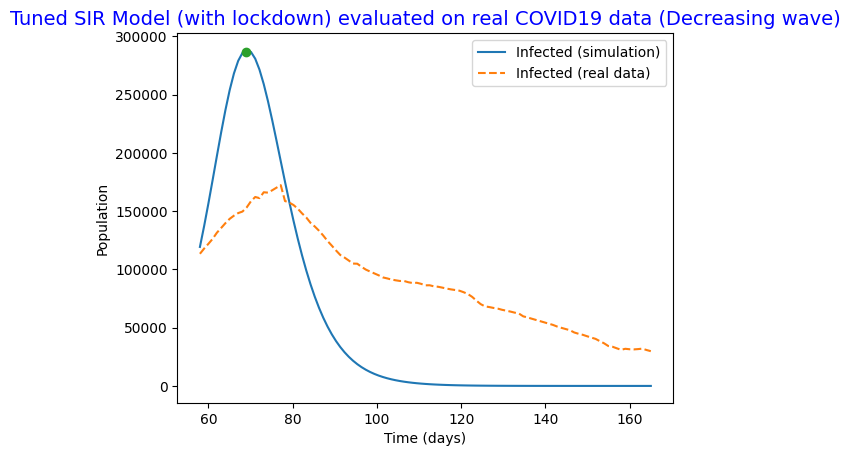

In [10]:
#Finally, we will test the model to the data
time=72
end=180 #we take the end of the data 

#we define again the time ranges and the real data according to it
dt1=np.linspace(time-start+1,end-start,end-time-1)
infected1=infected[time-start+1:]
n = end-time-1

#we initialize the variables with the correct values
a =1/2.3 #in days
y0 = (S1,I1,R1)
params = (opt_r, a, opt_q)
Y = odeint(qSIR, y0, dt1, args=params, hmax = 1.0)
S = Y[:,0]; I = Y[:,1]; R = Y[:,2];

#and we find the rmse obtained
mse = np.square(np.subtract(infected1, I)).mean() 
rmse = math.sqrt(mse)
#print('The root mean squared error is: ' + str(round(rmse,2)))

Imax=max(I) #at this point, the derivative of I will be 0
idx1=np.where(I==Imax) #we look for the index where the peak is located
idx1=idx1[0][0]+1 #the next index will be when dI/dt<0
idx=idx1+time-start #we have to add the time in the increasing wave minus the delay
print("where dI/dt < 0: " + str(idx) + " days, so April 15th, 2020.")

#we plot all the results
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, I, label="Infected (simulation)")
plt.plot(dt1, infected1, '--', label='Infected (real data)')
plt.plot(idx,I[idx1],'o')
plt.title("Tuned SIR Model (with lockdown) evaluated on real COVID19 data (Decreasing wave)", color='blue', fontsize=14)
plt.legend()
plt.show()

#we print the predictions

### **4. CONCLUSIONS ON SIR MODEL WITH QUARANTINE IMPLEMENTED**

As we can see, there is no much improvement when quarantine is implemented, what is more, there is more error in the prediction: 61 days. This can be explained because of the high asymmetry that our data presents, as we have previously explained. This asymmetry is highly likely to be the main problem, because the fitting is done in the increasing wave, which is more similar to the increasing wave of the model, so it fits it better. Also, the worsening of the prediction can be due to the implementatio of the factor $q$, which makes the wave decrease faster. 

However, the model that is now tuned to fit the first section of the wave has to be evaluated on the decreasing part of the wave, and this section of the data is more different and has a slope less steep than in the first part. Consequently, since the model does not aim to fit the decreasing part, the error obtained in the evaluation is very high, and visually, the model is not accurate. So, taking into account the limitations that we have seen when evaluating the SIR model without quarantine, there are still a lot of factors that worsen the output. 

In first place, the latency period is still not considered, which is an important aspect when studying the COVID19 pandemics, since the individuals first go through an incubation process, they do not get infected in the first place. In addition, as well as in the previous case, the complexity of the disease is not taken into account, so there are people that get infected easily, which may be due to immunity or caution. Finally, the correct complexity of connections of infections among the population are not well modelled, and although s0 is fitted to correct this, the problem is not completely resolved. 



## **SEIR MODEL**
### **1. THEORETICAL BACKGROUND**
The SEIR model is a further development of the SIR model, which considers that the infected population first goes through a latency phase during which they can not infect other individuals. Therefore, the population is divided in four groups: susceptible (S; amount of population that risks being infected), exposed (E; amount of population that has been exposed and infected, but is not yet infectious), infected (I; amount of population that is infected and can infect others), and removed (R; individuals that are either dead or immune for life). \\
The SEIR model is also defined with ordinary differential equations (ODEs), therefore being a deterministic model with continuous time, and according to the following parameters:


*   $r$, the infecivity of the disease
*   $a$, the constant per capita recovery rate
*   $\eta$, the incubation rate (rate of latent individuals becoming infectious)

Consequently, the set of differential equations that drive the model are:

$\frac{dS}{dt}=-rSI$ \\
$\frac{dE}{dt}=rSI - \eta E$ \\
$\frac{dI}{dt}=\eta E - aI$ \\
$\frac{dR}{dt}=aI$ 


In the following code block, the SEIR model is defined and its plot is displayed. 

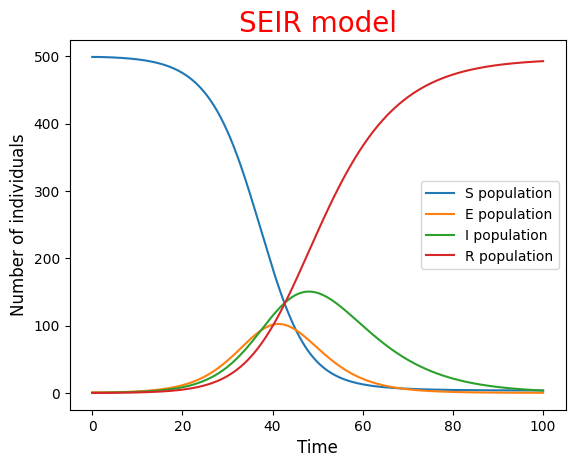

In [11]:
#constants and variables definition
r_theory=1e-3
a_theory=1e-1
eta_theory = 1/5.2
params_theory=(r_theory,a_theory,eta_theory)
S0_theory=499
E0_theory=1
I0_theory=0
R0_theory=0
SEIR0_theory=[S0_theory,E0_theory,I0_theory,R0_theory]
t_theory=np.linspace(0,100,1000)

#definition of the SEIR function
def SEIR(ys_at_t, t, *parameters):
    r = parameters[0]
    a = parameters[1]
    eta = parameters[2]
    S, E, I,R = ys_at_t
    dSdt = -r*S*I
    dEdt = r*S*I-eta*E
    dIdt = eta*E - a*I
    dRdt = a*I
    return dSdt, dEdt, dIdt, dRdt

#call the SEIR function
SEIR_theory = odeint(SEIR, SEIR0_theory , t_theory, args=params_theory)
S_theory = SEIR_theory[:,0]; E_theory = SEIR_theory[:,1]; I_theory = SEIR_theory[:,2] ; R_theory = SEIR_theory[:,3]

#plot the results
plt.figure()
plt.plot(t_theory, S_theory)
plt.plot(t_theory, E_theory)
plt.plot(t_theory, I_theory)
plt.plot(t_theory, R_theory)
plt.xlabel("Time", fontsize = 12)
plt.ylabel("Number of individuals", fontsize = 12)
plt.title("SEIR model", fontsize = 20, color="red")
plt.legend(labels=["S population", "E population", "I population", "R population"],loc='best')
plt.show()

### **2. DEFINITION OF VARIABLES**
Same as before, the data that we are given is not directly structured in the four groups that are useful for the SEIR model. The real data is handled exactly the same way as before, split it into three groups: infected, susceptible and removed. As a reminder, this is done considering that infected population is the number of confirmed cases minus the recovered and dead population. \\ 

Since the data is split into three groups and the model considers four groups, which makes comparison between data and the model more difficult. To try and kepp a certain order, from now on the infected group of the real data will be compared to the exposed (E) group of the SEIR model. This is because the people that is classified as infected are those confirmed cases that have not recovered yet, which would encompass both the exposed and the infected group of the SEIR model. However, the exposed group varies accordingly to new infections (such as the "infected" data), while the infected group varies with a certain delay given by η. Taking all this into consideration, the error will be computed from the substraction of E from the infected data. \\

Additionally, the variables `time` and `start` have been defined as before and are used similarly. Also same as before, only the infected and removed populations are plotted over time, since S0 has not yet been fitted for the SEIR model.

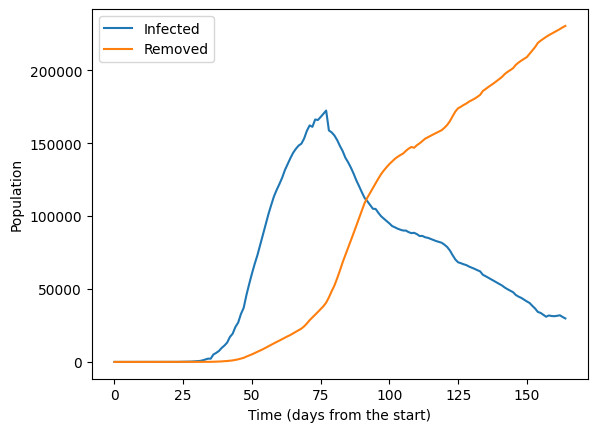

In [12]:
#we separate the values in variables
infected = [] #we define the variables as lists
removed = []
time=180 #we determine the time interval to later do the fitting with our model
start=15 #we start with some delay in order for the signals to fit better

for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i]) #we substract from the confirmed cases all the deaths and the recovered 
  removed.append(deaths1[i]+recovered1[i])#we add both the dead and the recovered people to the remove compartment

#susceptible = s0 - confirmed1
dt=np.linspace(0,time-1-start,time-start) #we define the time variable according to the start and the end 


#we plot the data to see the behavior
plt.figure()
plt.plot(dt,infected) 
plt.plot(dt,removed)
plt.xlabel("Time (days from the start)")
plt.ylabel("Population")
labels=['Infected','Removed']
plt.legend(labels)
plt.show()

### **3. FITTING OF $r$ AND $S_{0}$**
As it was already commented, the main aim of this project is to fit, as better as possible, the models to the data. In this case, we will be fitting $r$ (infectivity) and $S_{0}$, which determines the initial amount of susceptible people among the population, with the SEIR model. The other parameters already have a given value, with $a=1/7.5$ $days^{-1}$ and $\eta=1/5.2$ $days^{-1}$. It should be noted that the value of a is smaller than with the SIR model because the period of incubation is also taken into account, so that the total period of infection is 7.5 days. \\

Same as before, only the increasing wave will be fitted and as a result, a set of values will be fixed for parameters $r$ and $S_{0}$, which will be the ones that give the less amount of error when the modelled data is compared to the real one. As has been shown, some rougher tunning has been performed previously with the given data. This has enabled a finer tunning of the parameters between more precise values. As it can be seen in the code below, the range of values for $r$ is [$10^{-7},10^{-6}$], whereas the range values for $S_{0}$ is [$6·10^{5},1·10^{6}$]. \\

The next step is to run the model to find the best combination of the two parameters, and to come to a conclusion, the root mean squared error will be calculated between the resulting modelled signal and the real one, until an optimal resulting combination of values is met.

min rmse: 28830.35 with r: 7.28e-07 and S0: 889655.17
relative rmse: 3.24%


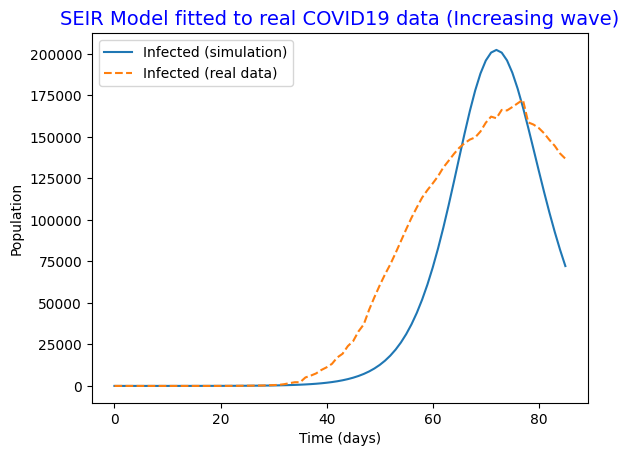

In [13]:
#SEIR MODEL, fitting of r and S0
dt=np.linspace(0,time-1-start,time-start)
n=time-start

index_max=infected.index(max(infected)) #fitting only of the increasing wave
increasing_wave=85 #the maximum is 77 (peak location), but we will delay the fitting to 85 days instead because of the asymmetry if the data

infected1=infected[0:increasing_wave+1] #we only take the infected data up to the peak previously found
n=increasing_wave+1 #this variable will define the length of the arrays of I, R and S
dt=np.linspace(0,increasing_wave,increasing_wave+1) #this is the time variable of the differential equations

#different values for r and S0
rates = np.logspace(-7,-6,num=30) 
S0 = np.linspace(6e5,1e6,30)

#declare constants and initial condition
a=1/7.5 #in days^-1
nu=1/5.2
I0=0
R0=0
E0=2 #2 exposed instead of 2 infected at the start

#declare empty variables
rmserrors=np.zeros((len(rates),len(S0)))
S=np.zeros((n,len(rates),len(S0)))
I=np.zeros((n,len(rates),len(S0)))
R=np.zeros((n,len(rates),len(S0)))
E=np.zeros((n,len(rates),len(S0)))

#try all combinations
for i in range(len(rates)):
  params = (rates[i],a,nu)
  for j in range(len(S0)):
    y0=(S0[j],E0,I0,R0)
    Y = odeint(SEIR, y0, dt, args=params, hmax = 1.0)
    S[:,i,j] = Y[:,0]; E[:,i,j] = Y[:,1]; I[:,i,j] = Y[:,2]; R[:,i,j] = Y[:,3];
    mse = np.square(np.subtract(infected1, E[:,i,j])).mean() 
    rmse = math.sqrt(mse)
    rmserrors[i,j]=rmse

#look for the best combination (minimal RMSE) and extract the parameters
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)
opt_r=rates[index[0]]#best r
opt_s0=S0[index[1]]#best S0
relative_error=100*min_error/opt_s0
print ('min rmse: ' + str(round(min_error,2)) + ' with r: ' + str(round(opt_r[0],9)) + " and S0: " + str(round(opt_s0[0],2)))
print('relative rmse: ' + str(round(relative_error[0],2)) + str("%"))

#plot the results
plt.figure(6)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, E[:,index[0],index[1]], label="Infected (simulation)")
plt.plot(dt, infected1, "--", label='Infected (real data)')
plt.title("SEIR Model fitted to real COVID19 data (Increasing wave)", color='blue', fontsize=14)
plt.legend()
plt.show()

### **4.EVALUATION OF THE MODEL ON THE DECREASING WAVE**

At this point, the model has already been tuned with the parameters that result in the best outcome for the increasing wave. Now, same as with the SIR model, these obtained parameter values will be used to predict how the model will behave in the decreasing wave, which will be compared to the real data using the root mean squared error. 

Also same as before, we will use this model to predict approximately when the epidemics will end. This should be done by considering the end to be when the infected population reaches a 30% of its maximum. However, since the real data does not reach the 30% value on the decreasing wave (at least not on the first wave), the last value of the wave will be used.

The root mean squared error is: 67956.44


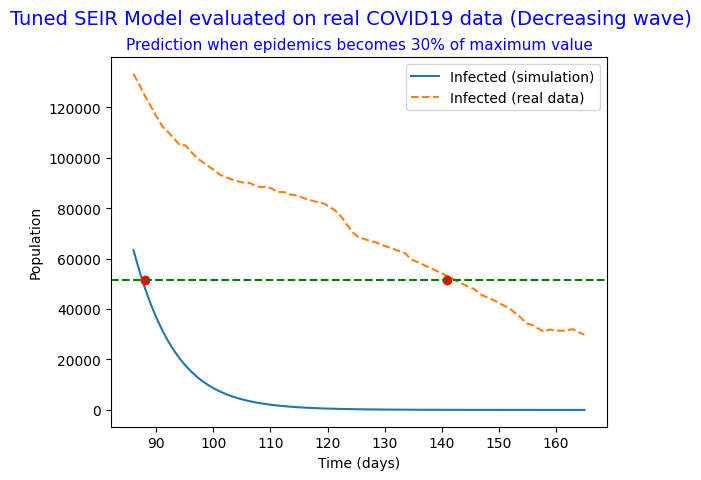

Pandemic ends at 88 days (according to simulation), so 4th May, 2020.
Pandemic ends at 141 days (according to real data), so 27th June, 2020.
Error of prediction between model and real data: 53 days.


In [16]:
infected = []
removed = []

#start and end for the decreasing wave
time=180
start=15

#select the data
for i in range(start,time):
  infected.append(confirmed1[i]-deaths1[i]-recovered1[i])
  removed.append(deaths1[i]+recovered1[i])

index_max=infected.index(max(infected)) #fitting only of the increasing wave
infected1=infected[increasing_wave+1:]#select from infected

dt=np.linspace(0,time-1-start,time-start) #this is the time variable in general
dt1=np.linspace(increasing_wave+1,time-start,time-increasing_wave-start-1) #this is the time variable of the differential equations in this specific case 

#declare constants again
a=1/7.5 #in days
nu=1/5.2
I0=0
R0=0
E0=2
params = (opt_r,a,nu)
y0 = (opt_s0,E0,I0,R0)

#compute the results
Y = odeint(SEIR, y0, dt, args=params, hmax = 1.0)
S = Y[:,0]; E = Y[:,1]; I = Y[:,2]; R=Y[:,3];
mse = np.square(np.subtract(infected1, E[increasing_wave+1:])).mean() 
rmse = math.sqrt(mse)
print('The root mean squared error is: ' + str(round(rmse,2)))

#Last, we obtain the time at which the epidemics is supposed to end for real and modelled data
val=max(infected)*0.3 #as we have explained, we will take the 30% of the maximum infected population

#we find the 30% for the modelled infected
trobat=False
i=increasing_wave
idx1=0
while i<(len(E)) and not trobat:
  if E[i]<val:
    trobat=True
    idx1=i
  i+=1

#we also find it for the real infected
i=0
idx2=0
trobat=False
while i<len(infected1) and not trobat:
  if infected1[i]<val:
    trobat=True
    idx2=i+increasing_wave
  i+=1

#plot the results
plt.figure(6)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, E[increasing_wave+1:], label="Infected (simulation)")
plt.plot(dt1, infected1, "--", label='Infected (real data)')
plt.plot(idx1,val,'ro')
plt.plot(idx2,val,'ro')
plt.axhline(y=val, color='g', linestyle='--' )
plt.suptitle("Tuned SEIR Model evaluated on real COVID19 data (Decreasing wave)", color='blue', fontsize=14)
plt.title('Prediction when epidemics becomes 30% of maximum value', fontsize=11, color='blue')
plt.legend()
plt.show()

#print the results
print("Pandemic ends at " + str(idx1) + " days (according to simulation), so 4th May, 2020.")
print("Pandemic ends at " + str(idx2) + " days (according to real data), so 27th June, 2020.")
print("Error of prediction between model and real data: " + str(idx2-idx1) + " days.")

### **5. ANALYSIS OF BASIC REPRODUCTIVE RATIO AND EPIDEMICS**

As shown before, the SIR model has been completely understood and predicted with theuse of the basic reproductive ratio ($R_{0}$). However, since the mathematical expression of the equations governing the SEIR model is different to the ones for the SIR model, the given expression for $R_{0}$ are not completely accurate. Nevertheless, we have used it to predict when the epidemic will start decreasing (when it reaches its peak). We have also computed when the derivative of both the I and E variables becomes negative, which should also yield the point at which the infected and exposed population decrease, respectively. However, as it is shown, neither of those happend at the same time as when $R_{0} < 1$. This is basically due to the fact that this ratio is based on the equations of the SIR model instead of on the equations of the SEIR model. Considering that the basic reproductive ratio is defined as $R_0 = r·S_{0}/a$, it becomes $R_0 > 1$ when $r·S > a$. In the SIR model this was the equivalent of having $dI/dt > 0$, but in the SEIR model this would be the equivalent of having $dI/dt + dE/dt = r·S - a > 0$. Therefore, it is logical that the moment at which $R_0 < 1$ does not correspond to the moment where the Exposed curve nor the Infected curve reach their maxima (even if it is quite close). However, the point where the basic reproductive ratio will be between these two maxima, since it depends on both variables in the SEIR model.

Another way of seeing this is by looking for the reproductive ratio that becomes equal to one exactly when the derivative of the exposed population becomes 0. By isolating for the expressions of the SEIR model the following expression would be obtained: $R = r·S·I/\eta·E$. However, this expression depends on both the exposed and infected population and is therefore difficult to predict, so it does not constitute a useful parameter to understand the evolution of an epidemic.

where R0 < 1: 75.0 days, so 21st April, 2020.
where dE/dt < 0: 72.0 days, so 18th April, 2020.
where dI/dt < 0: 77.0 days, so 23rd April, 2020.


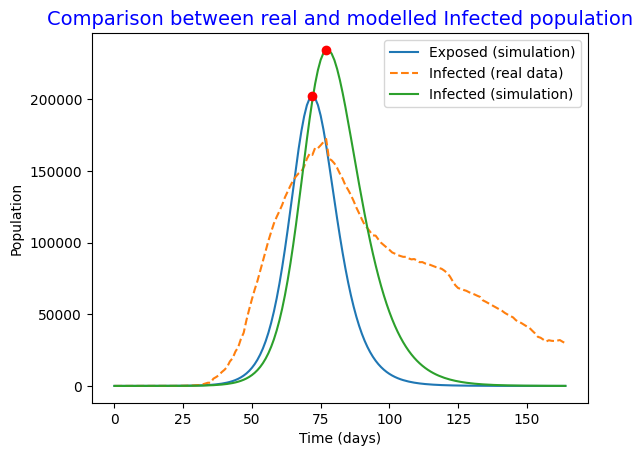

In [17]:
#declare parameters
r = opt_r
S0 = opt_s0
a=1/7.5 #in days
eta=1/5.2 #in days
I0=0
R0=0
E0=2
params = (r,a,eta)
y0=(S0,E0,I0,R0)
Y = odeint(SEIR, y0, dt, args=params, hmax = 1.0)
S= Y[:,0]; E = Y[:,1]; I = Y[:,2]; R = Y[:,3];

#declare R0 variable
r0=r*S/a

#find the peak for E, for I and for R0
Emax=max(E)
idx1=np.where(E==Emax) #derivative of E =0
idx2=np.where(r0<=1) #R0 becomes <1
idx3=np.where(I==max(I))#derivative of I =0
idx2=idx2[0][0]
idx1=idx1[0][0]
idx3=idx3[0][0]
#print results
print("where R0 < 1: " + str(dt[idx2])+ " days, so 21st April, 2020.")
print("where dE/dt < 0: " + str(dt[idx1])+ " days, so 18th April, 2020.")
print("where dI/dt < 0: " + str(dt[idx3])+ " days, so 23rd April, 2020.")

#plot graph
plt.figure(7)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, E, label="Exposed (simulation)")
plt.plot(dt, infected,"--", label='Infected (real data)')
plt.plot(dt, I, label="Infected (simulation)")
plt.title("Comparison between real and modelled Infected population", fontsize=14, color='blue')
plt.plot(dt[idx1],E[idx1],'ro') #we mark the first point where R0 < 1 and dI/dt <0 (it's the same value)
plt.plot(dt[idx3],I[idx3],'ro') #we mark the first point where R0 < 1 and dI/dt <0 (it's the same value)
plt.legend()
plt.show()

### **6. CONCLUSIONS ON SEIR MODEL**

The fitting of the SEIR model to the data of the COVID19 pandemic and its later prediction of the decreasing wave has led us to some conclusions on the adequacy of this model regarding epidemics. It should be commented that the limitations of the regular SEIR model are similar to those of the SIR model, even if it considers an extra state variable. The RMSE of the fitting (increasing wave) is 28830.35 people, while the RMSE of the data used for prediction (decreasing wave) is 67956.44 people. It can be seen that the error of the increasing wave is much lower than that of the decreasing wave, which is logical, considering that the parameters were fitted for the increasing wave, and not for the decreasing wave. Additionally, the RMSE of the SEIR model has a similar value as the RMSE of the SIR model, even if it is slightly greater. This means that in this case the SEIR model yields a very similar approximation to the given data to the approximation obtained with the SIR model. On the other hand, from computing the prediction when the infected population reaches the 30% of its maximum value, we have obtained a result with an error of 53 days. This means that our model predicts the end of the epidemic nearly two months before its actual end. This is also very similar to the result obtained with the SIR model, what further confirms that these two model yield very similar results.

The main limitations of this model, which increase the RMSE of the fitting and predictions are the following ones:

*   The asymmetry of the data, since the SEIR model is also a symmetrical model.This is also related to the fact that the population that i sbeing studied is really big, so it is much more difficult to model since there might be different outbreaks at different times in different places, which widen the infections curve. Therefore, since the SIR and SEIR model only consider a whole population, this phenomenon is not taken into account
*   The SEIR model also assumes the population to be a closed system, so neither migrations nor births or deaths due to other reasons are considered.
*   The disease presents a level of complexity that is not contemplated on the SEIR model either: same as before, different levels of severity, as well as other particular characteristics of the infection are not considered. However, the latency of the infectionn is now considered within the Exposed group, thus making the model more realistic than the SEIR model.
*   The lack of more compartments should also be considered for this model. Even with the addition of the Exposed compartment (in comparison with the SIR model), having more compartments would probably help model the infections better.
*   There is also the effect of "noise" in the real data, which does not appear in the model's obtained results. The actual number of infected people depends on many factors, but also has a non-deterministic nature, as all variables with finite samples. Therefore, it presents a certain random noise that is not observed in the model's output, since it is using a mathematical formula.
*   Same as with the SIR model, quarantine has not yet been added to the equations, therefore leaving out a very important variable that changed the evolution of the pandemic in its midst.
*   Finally, same as with the SIR model, the SEIR model also assumes a well-mixed population, when in reality not all population is in contact with each other. This has been somewhat considered when fitting $S_{0}$, but that is also widely inaccurate: in real life the susceptibility to become infected does not only depend on the initial susceptible population but also on different population groups' characteristics (such as gender, age, correct accomplishment of health guidelines, etc.). However, this is very difficult to model, since it would require a really good understanding of the population (which in this case is really big) and a presonalised model, which would not be able to generalise.

Consequently, it can be concluded that the SEIR model is not quite accurate, same as the SIR model. It gives a huge error in its predictions and lacks predictive power especially with regard to the end of the epidemic. Therefore this model on its own is not a good representation of reality either.







## **SEIR MODEL: QUARANTINE**

For this section, quarantine will be taken into account to carry out a better model tuning, same as with the SIR model. We will first proceed to fit the model to the data during the days where quarantine was not implemented, with the main aim to obtain the parameters $r$ and $S_{0}$. After that, we will fit the data of the following period of time (during which quarantine is implemented) to obtain a value for the quarantine parameter $q$. Finally, using all these obtained parameters, the model will be tested on the last part of the data, where the end of the epidemic will also be predicted.

### **1. FITTING OF $r$ AND $S_{0}$**

Same as before, the days that had passed from the start of the data to where the lockdown started were 52 days. However, this number of days did not result in a good fitting (as with the SIR model), so we have assumed the quarantine to start after 72 days. It is important to remember that the 72 days are counted from the start of the real data and some days have been removed (at the start), so the graph does not reach 72 days. 

In this case, since we are using the SEIR model, the incubation period of the disease is being taken into account, contrary to the SIR model. However, the effect of lockdown is considered to appear some days after the imposition of quarantine, not the same day that i was implemented. Therefore, it still makes sense to delay it some days.

As well as in the previous case, the code below represents a tunning where the interval values taken for each parameter are: $[10^{-9}, 10^{-4}]$ for $r$ and $[1·10^{6},8·10^{6}]$ for $S_{0}$. We have also performed a finer tuning to obtain the values that we give at the end of this same code, but we wanted to show a rougher tunning (within a wider range of values) in addition to the finer tunnings that we have already shown.

The minimum RMSE is: 10000.330522285589 with r: 2.6e-07 and S0: 5103448.28


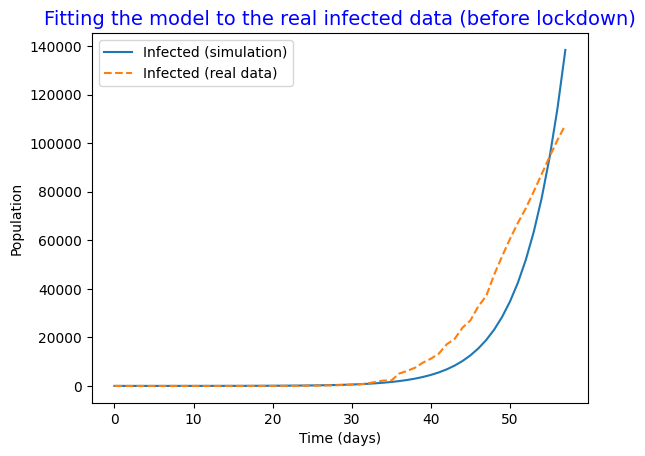

In [18]:
#Model SEIR, fitting of r (he fet amb valors que més s'apropen)

#susceptible = s0 - confirmed1
time=72 #haurien de ser 52 pero no va be
index_max=infected.index(max(infected)) #fitting only of the increasing wave

#redeclare infected data and time
infected1=infected[0:time-start+1]
n=time-start+1
dt=np.linspace(0,time-start,time-start+1)

#different rates and S0
rates = np.logspace(-9,-4,num=30) 
S0 = np.linspace(1e6,8e6,30)

#declare parameters and initial conditions
a =1/2.3 #in days^-1
eta=1/5.2 #in days^-1
I0=0
E0=2
R0=0

#empty variables
rmserrors=np.zeros((len(rates),len(S0)))
S=np.zeros((n,len(rates),len(S0)))
E=np.zeros((n,len(rates),len(S0)))
I=np.zeros((n,len(rates),len(S0)))
R=np.zeros((n,len(rates),len(S0)))

#try all combinations
for i in range(len(rates)):
  params = (rates[i],a, eta)
  for j in range(len(S0)):
    y0 = (S0[j],E0,I0,R0)
    Y = odeint(SEIR, y0, dt, args=params, hmax = 1.0)
    S[:,i,j] = Y[:,0]; E[:,i,j] = Y[:,1]; I[:,i,j] = Y[:,2]; R[:,i,j] = Y[:,3];
    mse = np.square(np.subtract(infected1, E[:,i,j])).mean() 
    rmse = math.sqrt(mse)
    rmserrors[i,j]=rmse

#Find the minimal error (and the corresponding parameters)
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)
opt_r=rates[index[0]]
opt_s0=S0[index[1]]

#print the result
print ('The minimum RMSE is: ' + str(min_error) + ' with r: ' + str(round(opt_r[0],8)) + " and S0: " + str(round(opt_s0[0],2)))

#plot the result
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, E[:,index[0],index[1]], label="Infected (simulation)")
plt.plot(dt, infected1,"--", label='Infected (real data)')
plt.legend()
plt.title("Fitting the model to the real infected data (before lockdown)", color='blue', fontsize=14)
plt.show()

#create a variable for the whole evolution and E and I (will fill it later)
Efinal = np.zeros((164,1))
Efinal[0:58] = E[:,index[0],index[1]]
Ifinal = np.zeros((164,1))
Ifinal[0:58] = I[:,index[0],index[1]]

#save final values for the starting values of the next section
I1 = I[-1,index[0],index[1]][0]
E1 = E[-1,index[0],index[1]][0]
S1 = S[-1,index[0],index[1]][0]
R1 = R[-1,index[0],index[1]][0]

### **2. FITTING OF THE QUARANTINE FACTOR $q$**

The quarantine factor $q$ will be fitted the same way as the SIR model. We will use the optimal $r$ and $S_{0}$ that have been already fitted and we will fix them in this case. Added to this, we will fit the section of increasing wave left as well as a section of the decreasing wave, in order for the fitting to work better. Again, the code shows a pretty rough tunning, rather than a finer tunning, since we wanted to show how we have performed both procedures throughout the code. In this case the range of shown values of q belongs within $[10^{-3},1]$. However, a finer tunning has also been performed to obtain the given value. It should be noted that the obtained value is in fact 1, and that it would have a slightly greater value if the values of q had not been limited between 0 and 1. However, for clarity's sake we have decided to mantain the q within this range of values, especially since the result does not differ significantly.

min rmse: 20706.1076399895 with q: 1.0


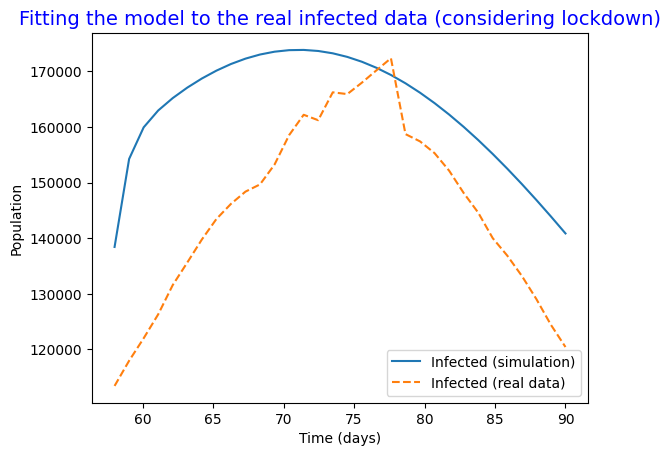

In [19]:
timef = 90 #we take until half of the decreasing wave to do the fitting

#we redefine the time interval and the infected real data in this time range
dt1=np.linspace(time-start+1,timef,timef-time+start-1)
infected1=infected[time-start+1:timef]
n = timef+start-time-1

#define SEIR with quarantine factor
def qSEIR(ys_at_t, t, *parameters):
    r = parameters[0]
    a = parameters[1]
    eta = parameters[2]
    q = parameters[3]
    S,E,I,R = ys_at_t
    dSdt = -r*S*I
    dEdt = r*S*I - eta*E
    dIdt = eta*E - a*I - q*I
    dRdt = a*I + q*I
    return dSdt, dEdt, dIdt, dRdt

#different values of q
qs = np.logspace(-3,0,30)

#declare constants
a =1/7.5 #in days
y0 = (S1,E1,I1,R1)#starting values from the final values of the previous section

#declare empty variables
rmserrors=np.zeros((len(qs),1))
S=np.zeros((n,len(qs)))
E=np.zeros((n,len(qs)))
I=np.zeros((n,len(qs)))
R=np.zeros((n,len(qs)))


#try all values of q
for i in range(len(qs)):
  params = (opt_r,a,eta, qs[i])
  Y = odeint(qSEIR, y0, dt1, args=params, hmax = 1.0)
  S[:,i] = Y[:,0]; E[:,i] = Y[:,1]; I[:,i] = Y[:,2]; R[:,i] = Y[:,3];
  mse = np.square(np.subtract(infected1, E[:,i])).mean() 
  rmse = math.sqrt(mse)
  rmserrors[i]=rmse

#find the best value (minimal error)
min_error=np.amin(rmserrors)
index=np.where(rmserrors==min_error)[0][0]
opt_q=qs[index]
print ('min rmse: ' + str(min_error) + ' with q: ' + str(opt_q))

#plot the result
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, E[:,index], label="Infected (simulation)")
plt.plot(dt1, infected1,"--", label='Infected (real data)')
plt.title("Fitting the model to the real infected data (considering lockdown)", color='blue', fontsize=14)
plt.legend()
plt.show()

#save to the whole variable of E and I (for all time)
Efinal[58:90,0] = E[:,index]
Ifinal[58:90,0] = I[:,index]

#we define the last conditions of the variables as the initial conditions for the next step
I2 = I[-1,index]
E2 = E[-1,index]
S2 = S[-1,index]
R2 = R[-1,index]

### **3. EVALUATION OF THE MODEL ON THE DECREASING WAVE**

For this last step shows the testing and prediction of the SEIR model with the obtained values for the parameters on the last part of the decreasing wave. Therefore, now we will take the optimal results of the parameters $r$, $S_{0}$ and $q$. The same that was done for the evaluation of the SEIR model on the decreasing wave without quarantine will be done in this case to calculate the prediction error. However, since the fitting is done by segments a 20% of the maximum infected population will be taken instead for this case, same as with the SIR model.

The root mean squared error is: 23086.41


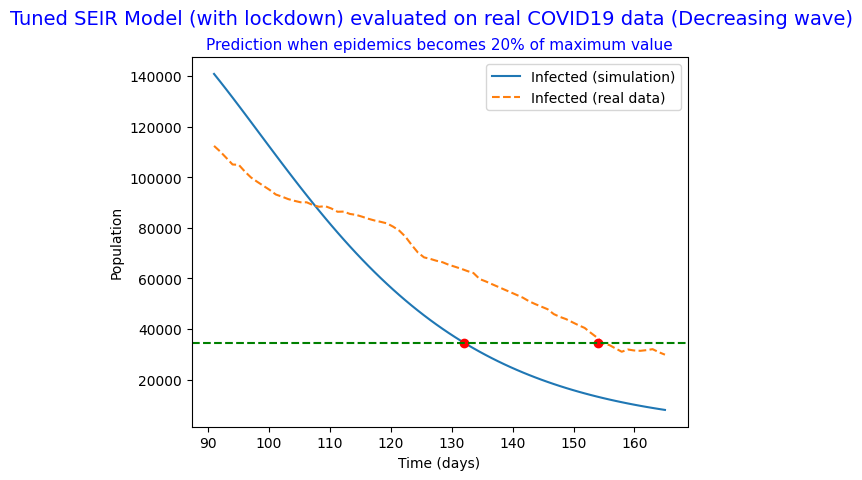

Pandemic is at its 30% after 132 days (according to simulation), so 18th June, 2020.
Pandemic is at its after 154 days (according to real data), so 9th July, 2020.
Error of prediction between model and real data: 22 days.


In [21]:
#define end and start times (and lengths)
end = 180 #we take until half of the decreasing wave to do the fitting
dt1=np.linspace(timef+1,end-start,end-start-timef-1)
infected1=infected[timef+1:]
n = end-start-timef-1

#define parameters (from the previous fitting)
a =1/7.5 #in days
y0 = (S2,E2,I2,R2)
params = (opt_r, a, eta, opt_q)

#compute result
Y = odeint(qSEIR, y0, dt1, args=params, hmax = 1.0)
S = Y[:,0]; E = Y[:,1]; I = Y[:,2]; R = Y[:,3];
mse = np.square(np.subtract(infected1, E)).mean() #compute RMSE
rmse = math.sqrt(mse)

#print result
print('The root mean squared error is: ' + str(round(rmse,2)))

#Last, we obtain the time at which the epidemics is supposed to end for real and modelled data
val=max(infected)*0.2 #as we have explained, we will take the 30% of the maximum infected population

#we find it for the modelled infected
trobat=False
i=0
idx1=0
while i<(len(E)) and not trobat:
  if E[i]<val:
    trobat=True
    idx1=i+timef+1
  i+=1

#we also find it for the real infected
i=0
idx2=0
trobat=False
while i<len(infected1) and not trobat:
  if infected1[i]<val:
    trobat=True
    idx2=i+timef+1
  i+=1

#plot the result
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt1, E, label="Infected (simulation)")
plt.plot(dt1, infected1, '--', label='Infected (real data)')
plt.plot(idx1,val,'ro')
plt.plot(idx2,val,'ro')
plt.suptitle("Tuned SEIR Model (with lockdown) evaluated on real COVID19 data (Decreasing wave)", color='blue', fontsize=14)
plt.title('Prediction when epidemics becomes 20% of maximum value', fontsize=11, color='blue')
plt.axhline(y=val, color='g', linestyle='--' )
plt.legend()
plt.show()

#obtain the whole variable for E
Efinal[90:,0] = E
Ifinal[90:,0] = I

#print results
print("Pandemic is at its 30% after " + str(idx1) + " days (according to simulation), so 18th June, 2020.")
print("Pandemic is at its after " + str(idx2) + " days (according to real data), so 9th July, 2020.")
print("Error of prediction between model and real data: " + str(idx2-idx1) + " days.")

Finally, in the following graph, the whole wave (both fitting and prediction) is shown, both for the real data as for the SEIR model. Conclusions regarding the obtained results are commented later.

where dE/dt < 0: 72 days, so 18th April, 2020.
where dI/dt < 0: 58 days, so 3rd April, 2020.


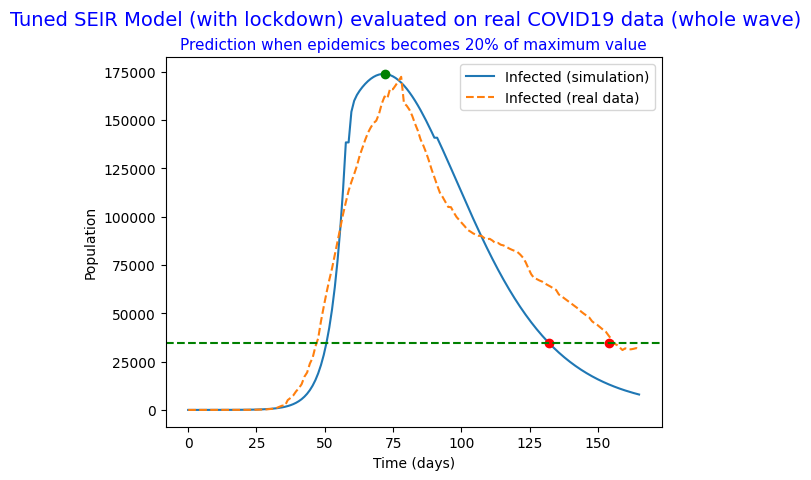

In [23]:
#declare whole time
dt=np.linspace(0,165,164)

#find the peak for E and for I
idxE=np.where(Efinal==max(Efinal)) #derivative of E =0
idxI=np.where(Ifinal==max(Ifinal))#derivative of I =0
idxE=idxE[0][0]
idxI=idxI[0][0]
#print results
print("where dE/dt < 0: " + str(round(dt[idxE]))+ " days, so 18th April, 2020.")
print("where dI/dt < 0: " + str(round(dt[idxI]))+ " days, so 3rd April, 2020.")

#plot the whole E variable over time
plt.figure(2)
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.plot(dt, Efinal, label="Infected (simulation)")
plt.plot(dt, infected[:-1], '--', label='Infected (real data)')
plt.plot(idx1,val,'ro')
plt.plot(idx2,val,'ro')
plt.suptitle("Tuned SEIR Model (with lockdown) evaluated on real COVID19 data (whole wave)", color='blue', fontsize=14)
plt.title('Prediction when epidemics becomes 20% of maximum value', fontsize=11, color='blue')
plt.plot(dt[idxE],Efinal[idxE],'go') #we mark the first point where dE/dt <0 
plt.axhline(y=val, color='g', linestyle='--' )
plt.legend()
plt.show()

As it can be seen, the point at which $dE/dt = 0$ occurs after 72 days, while the point at which $dI/dt = 0$ occurs after 58 days. Therefore, it oculd be interpreted that the moment at which $R_0 < 1$ and the epidemic starts to decrease should be somewhere close to those points. However, as has been already commented, this parameter is not adequate for describing models that include variables or parameters that differ from those of the SIR model. It is because of that that it is difficult to determine an exact value for $R_0$.

### **4. CONCLUSIONS ON SEIR MODEL WITH QUARANTINE IMPLEMENTED**

In this case, it can be seen that by adding a quarantine factor to the SEIR model, the prediction is significantly enhanced. First of all, the RMSE in the fitting of the first two parameters is of 10000.33 people, the RMSE in the fitting of the quarantine factor is of 20706.11 people, and the RMSE in the prediction of the decreasing wave is of 23086.41 people. It can be seen that even if the error of prediction is rather higher than the error of fitting, it does not vgary significantly. This means that the model has a greater ability to generalise and adapt to the given data than without including the quarantine factor. This is probably not only due to the addition of the quarantine factor but also due to the new split of the data. Since less days are used for the fitting of $r$ and $S_0$, the obtained parameters yield a curve that tends to ascend more and reach its peak later than when more data is used for the fitting. However, this effect is later compensated with the quarantine factor, which flattens the curve after the time where lockdown is first applied. This is precisely what makes this model better, since by splitting the function in two parts, the resulting model can be asymmetrical and therefore fit the real data better.

Regarding the prediction of the end of the pandemic (when the curve reaches 20% of its maximum value), the obtained error is much lower than that of the SEIR model without quarantine, since it is only of 22 days. This constitutes an inaccuracy of less than a month, which compared to the results that were obtained previously is a much more reliable result. Even then, it should be mentioned that the model always predict an earlier end to the epidemic than the real data. The errors that explain what this happens are the same as exposed before when commenting the SEIR model without quarantine, with th exception of the quarantine factor, which has now been implemented.

In addition to all of that, it should be commented that the fitting of the modeled has been performed in a somewhat biased manner. It would have been possible to perform the fitting of $r$ and $S_0$ to reduce the RMSE of the fitting much more (by trying some other values, which we have also tried). However, when the fitting is performed this way, the fitting of $q$ and the prediction  yield a much worse result. This is because with a better fitting of the first two parameters, the curve goes down much faster and yields a much higher RMSE for the prediction and the fitting of $q$. Thus, we have decided to keep this fitting to show how this model can adapt to a Covid outbreak, even if it needs to be performed with bias.



## **CONCLUSIONS**

As we have seen throughout the project, there are many factors that neither the SIR nor the SEIR model are able to consider. Some of those are data asymmetries, random noise, localized outbreaks in different populations within the whole country, limited contact with a certain number of people and lockdown periods. We have implemented lockdown periods as well as a fitting of the initial susceptible population to help solve some of these inaccuracies, but the result has not shown really signficant increases in its accuracy. However, we have been able to observe how the SEIR model with quarantine might yield a better result than the previously developed models, since it manages to take more situations into consideration (the Exposed group and the quarantine). These results have been observed with the computation of RMSE in both fitting and prediction, as well as the prediction of the time at which the epidemic will end and the time at which the epidemic will reach its peak. 

Taking all the explained errors into consideration, the model can be considered to more or less model the behavior of the COVID pandemic but with obvious limitations. Some enhancement of the model should be performed if more accuracy (although probably less generalisation capabilities) was needed. Probably using data of localised areas separately would help obtain much better results, rather than using the data of a whole country. In addition to that, some factor (other than $S_0$) could be implemented to take into account the limitations of interactions with other people that might lead to spread the disease. Finally, this models only consider a wave of the epidemic, and do not contemplate the possibility of reinfection (loss of immunity). Therefore, the model should also be adapted to further develop this aspects and take them into account.